#### Activity: Brooks Diagram

> How did this diagram of the Brooks use rational, moral and emotional appeal to make a case to its audience?

Rational: The visualization uses keywords, descriptions, specific numbers of people, and facts about the space.
Moral: The diagram shows how people had to move or crawl through the ship, revealing the inhuman conditions from different views.
Emotional: The ship visualizations make the conditions feel more real, creating strong feelings of injustice, anger, and sympathy.

#### Activity: Pulse

> How does it challenge our assumption about what a visualization can look like? What are the strengths and weaknesses of this example?

It grabs attention, but it is hard to understand because there is no legend or data source. The message of the data is unclear, it would be difficult to recreate, and since it is static, it may not work well for large datasets.

In [25]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
import PIL
import requests

In [26]:
tips = sns.load_dataset("tips")
print(tips)

     total_bill   tip     sex smoker   day    time  size
0         16.99  1.01  Female     No   Sun  Dinner     2
1         10.34  1.66    Male     No   Sun  Dinner     3
2         21.01  3.50    Male     No   Sun  Dinner     3
3         23.68  3.31    Male     No   Sun  Dinner     2
4         24.59  3.61  Female     No   Sun  Dinner     4
..          ...   ...     ...    ...   ...     ...   ...
239       29.03  5.92    Male     No   Sat  Dinner     3
240       27.18  2.00  Female    Yes   Sat  Dinner     2
241       22.67  2.00    Male    Yes   Sat  Dinner     2
242       17.82  1.75    Male     No   Sat  Dinner     2
243       18.78  3.00  Female     No  Thur  Dinner     2

[244 rows x 7 columns]


<Axes: xlabel='total_bill', ylabel='tip'>

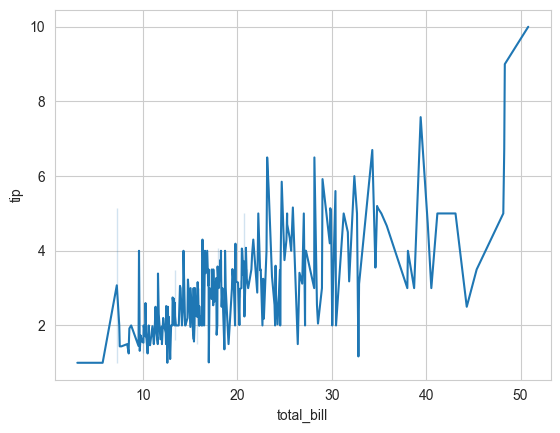

In [27]:
# sns.set_style('dark')
sns.set_style('whitegrid')
sns.lineplot(data=tips, # choose our dataset
             x='total_bill',    # define our x variable
             y='tip')   # define our y variable

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

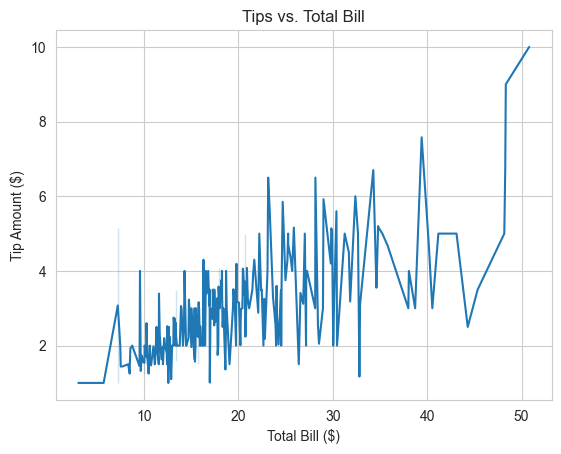

In [28]:
# add title and axis labels
tipgraph = sns.lineplot(data=tips,
                        x='total_bill',
                        y='tip')
tipgraph.set(title='Tips vs. Total Bill',
             xlabel='Total Bill ($)',
             ylabel='Tip Amount ($)')

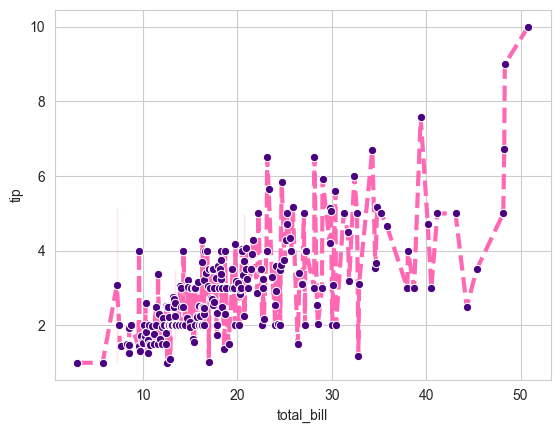

In [29]:
# modify aesthetic elements
tipgraph = sns.lineplot(data=tips,
                        x='total_bill',
                        y='tip',
                        color = 'hotpink',
                        linestyle = '--',
                        linewidth = 3,
                        marker = 'o',
                        markerfacecolor = 'indigo')

[Text(0.5, 1.0, 'Tips vs. Total Bill'),
 Text(0.5, 0, 'Total Bill ($)'),
 Text(0, 0.5, 'Tip Amount ($)')]

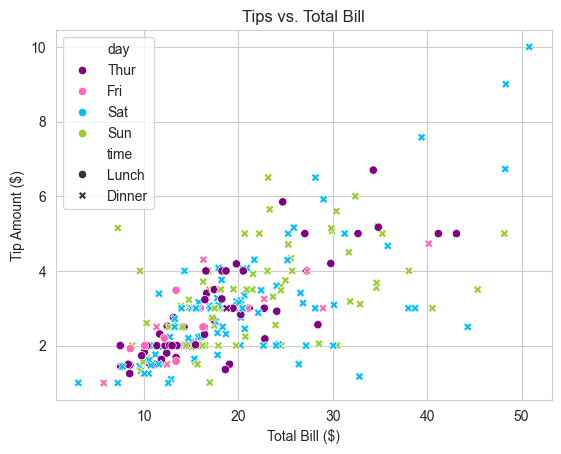

In [30]:
# add multiple variables
tipgraph = sns.scatterplot(data=tips,
                           x='total_bill',
                           y='tip',
                           style = 'time',
                           hue ='day', 
                           palette = ['purple','hotpink','deepskyblue','yellowgreen'])
tipgraph.set(title='Tips vs. Total Bill',
             xlabel='Total Bill ($)',
             ylabel='Tip Amount ($)')

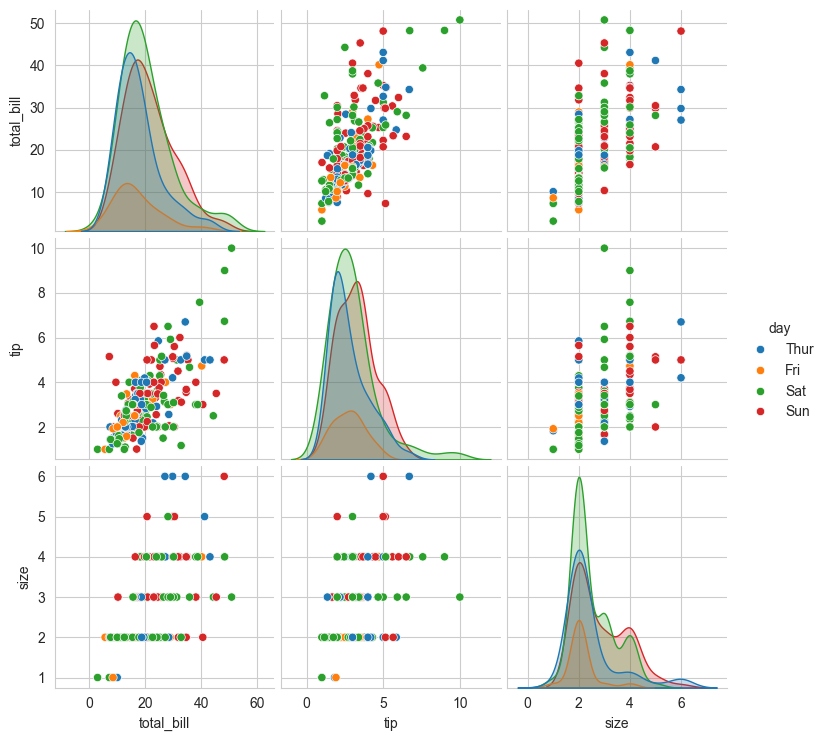

In [31]:
sns.pairplot(data = tips, hue = 'day')

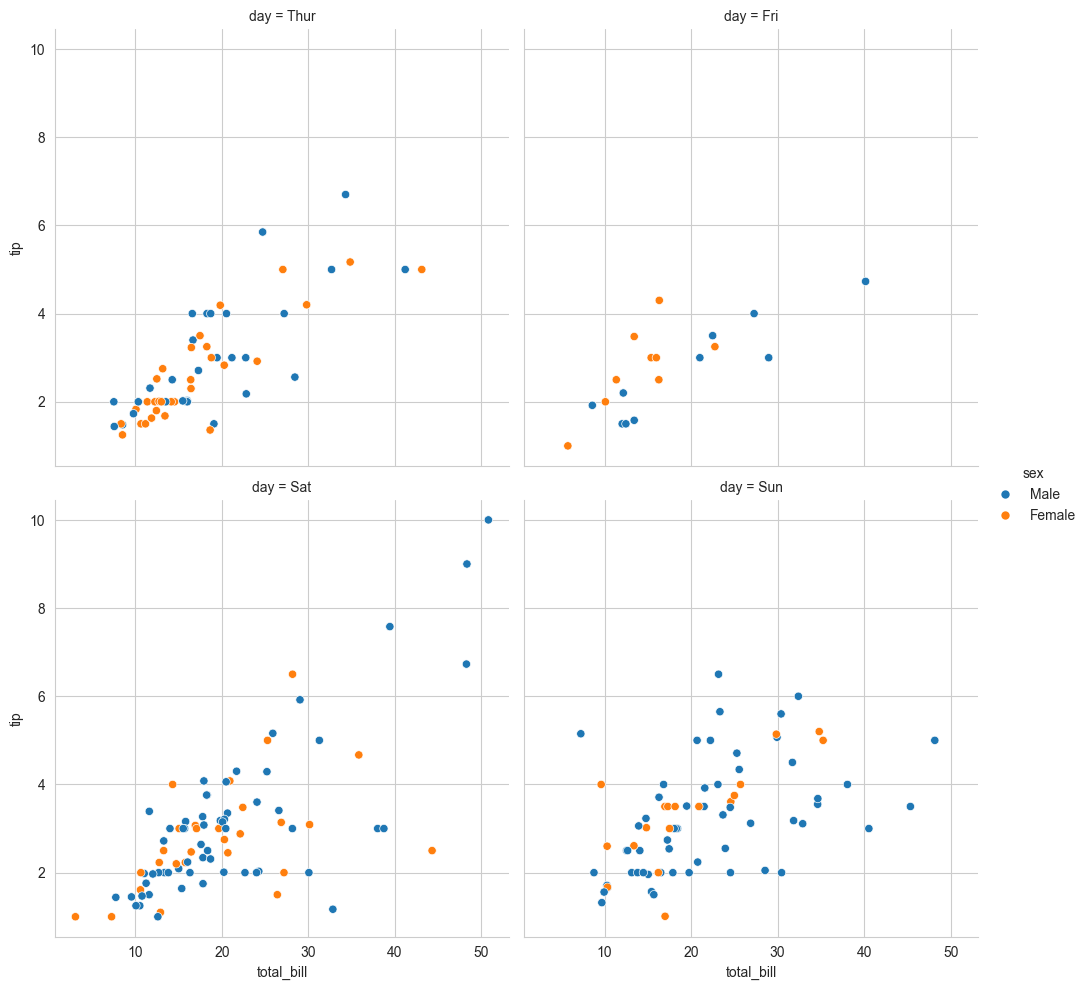

In [32]:
# replot to explore levels within variables
daysplot = sns.relplot(data=tips, 
                       x="total_bill", 
                       y="tip",
                       hue="sex",
                       col="day", 
                       kind="scatter", 
                       col_wrap=2) 

#### Activity: Comparing Data Visualizations

> How are they different? What does each visualization do?

The graph on the left is more static, while the graph on the right feels more dynamic. The left graph uses a smaller sample size and shows a specific group with exact counts, while the right graph gives a broader overall view.

> What are the pros and cons of each?

The right graph uses a larger dataset and shows more information and possible conclusions. It is easier to explore, but the counts may be less exact and the meaning can change depending on the words used. The left graph is easier to understand quickly because it is more descriptive and gives more accurate counts.


#### Activity: Types of Changes

> What types of changes occur when we interact with this dynamic data visualization?

Transactional or immediate

> Which spatial and retinal elements stay constant? Which change?

Frequency and points changes, colors stay constant.

> If you were redesigning this visualizatino, would you choose to make different changes? Why or why not?

The disciplines could be reordered to make it easier to compare the words directly.

In [33]:
import plotly.graph_objects as go # 'go' is 'graph objects’
x1 = np.array(["Luffy","Zoro","Nami","Usopp","Sanji"])
y1 = np.array([110, 180, 240, 99, 220])

graph = go.Figure()
graph.add_trace(go.Bar(x=x1, y=y1))

In [34]:
graph.update_layout(title="Pirate Scores",
                    xaxis_title="Pirates",
                    yaxis_title="Score")
graph.show()

In [35]:
graph.write_html("pirategraph.html")

In [ ]:
graph = go.Figure()
graph.add_trace(go.Scatter(x=x1, y=y1, mode='markers',  # points for scatter plot
marker=dict(size=15,    # point size
color='hotpink',        # point colour
opacity=1,              # point transparency/alpha
line=dict(width=5, color='purple'))))   # point outline
graph.update_layout(title='Interactive Pirate Plot',xaxis_title='Pirates',yaxis_title='Scores',width=500, height=500)

In [38]:
from wordcloud import WordCloud

In [39]:
df = pd.read_csv("https://raw.githubusercontent.com/prasertcbs/basic-dataset/master/movie_quotes.csv",
on_bad_lines='skip')
df

,quote,movie,type,year
0,"Do, or do not. There is no try.",Star Wars: Episode V - The Empire Strikes Back,movie,1890
1,Listen to them. Children of the night. What mu...,Dracula,movie,1931
2,It's alive! It's alive!,Frankenstein,movie,1931
3,"Oh, no, it wasn't the airplanes. It was Beauty...",King Kong,movie,1933
4,"Magic Mirror on the wall, who is the fairest o...",Snow White and the Seven Dwarves,movie,1937
...,...,...,...,...
727,I didn't know if you were lost. Stick with me....,Us,movie,2019
728,This guy's awesome! He's holding his own while...,Dragon Ball Super: Broly,movie,2019
729,"Murder is murder, it don’t matter who you are.",Black and Blue,movie,2019
730,You know what a lion is? A lion is a strong an...,Between Two Ferns: The Movie,movie,2019


(np.float64(-0.5), np.float64(399.5), np.float64(199.5), np.float64(-0.5))

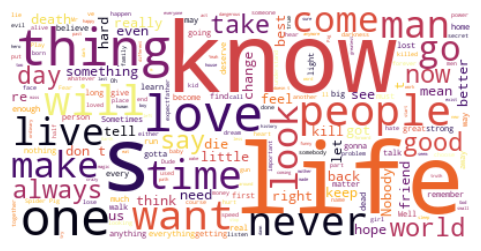

In [46]:
# join text from each row from quote column into a string
text = " ".join(each for each in df.quote)

# generate wordcloud image
wordcloud = WordCloud(background_color="white", colormap = 'inferno').generate(text)
fig, ax = plt.subplots(figsize=(7, 3))
ax.imshow(wordcloud, 
interpolation='bilinear')
ax.axis("off")

In [42]:
from matplotlib_venn import venn2, venn2_circles, venn2_unweighted

In [43]:
A = set(["apple","banana","watermelon"])
B = set(["pumpkin","blueberry","apple","key lime"])

/Users/vivianschu/repos/DSI/visualization/.venv/lib/python3.11/site-packages/matplotlib_venn/_util.py:32: UserWarning:

venn2_unweighted is deprecated. Use venn2 with the appropriate layout_algorithm instead.



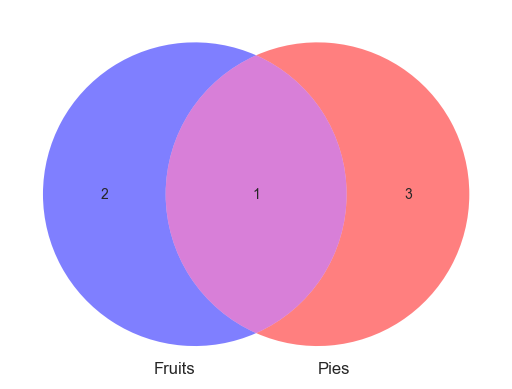

In [44]:
diagram = venn2_unweighted([A, B],set_labels = ('Fruits','Pies'),set_colors=("blue","red"),alpha=0.5)
plt.show()

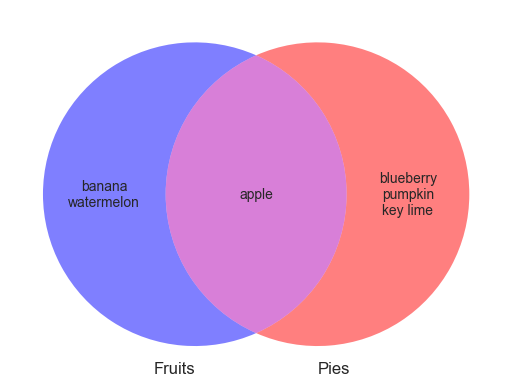

In [45]:
A = set(["apple","banana","watermelon"])
B = set(["pumpkin","blueberry","apple","key lime"])
diagram = venn2_unweighted([A, B],set_labels = ('Fruits','Pies'),set_colors=("blue","red"),alpha=0.5)

diagram.get_label_by_id("10").set_text("\n".join(A - B))
diagram.get_label_by_id("11").set_text("\n".join(A & B))
diagram.get_label_by_id("01").set_text("\n".join(B - A))
plt.show()